Contexte 
Une entreprise souhaite développer un système d’intelligence artificielle capable de reconnaître 
automatiquement le type de déchet présent sur une photographie afin d'améliorer le tri des 
déchets. 
Le modèle devra classer chaque image dans l'une des catégories suivantes : 

 cardboard : cartons ondulés, cartons plats, … 

 plastic : bouteilles, emballages plastiques... 

 paper : feuilles,  journaux... 

 glass : bouteilles et objets en verre... 

 metal : canettes, boîtes métalliques... 

 trash : emballages bonbons, tasses jetables, ... 
 
Le problème est que les images collectées proviennent de plusieurs sources. Elles ne sont donc pas 
homogènes : dimensions différentes ; formats différents ; images RGB et grayscale ; certaines images 
sont trop petites ; certaines images sont corrompues ; quelques images sont vides ; images 
dupliquées ; quelques images placées dans le mauvais dossier ; classes déséquilibrées. 
L'objectif de l'atelier est donc de construire un jeu de données images propre et homogène, prêt à 
être utilisé pour entraîner un modèle de Machine Learning ou de Deep Learning. 

Partie 1 –
 Exploration du dataset 
Développer un programme Python capable de récupérer, pour chaque image, son nom, sa classe, 
son format, son mode, sa largeur, sa hauteur, l’écart-type de ses pixels, son nombre de canaux et sa 
taille. 
NB : prendre en charge aussi les fichiers corrompus 

In [77]:
import glob
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

RAW_DIR = "../data/raw"
CLEAN_DIR = "../data/cleaned"
REPORTS_DIR = "../reports"

CLASSES = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

# Nombre de fichiers par classe
total = 0
for classe in CLASSES:
    fichiers = glob.glob(f"{RAW_DIR}/{classe}/*")
    total += len(fichiers)
    print(f"{classe:10s} : {len(fichiers)}")
print("Total fichiers :", total)

cardboard  : 169
glass      : 188
metal      : 149
paper      : 252
plastic    : 224
trash      : 50
Total fichiers : 1032


In [78]:
def lire_image(chemin, classe):
    """Retourne un dictionnaire d'infos sur une image (corrompue ou non)."""
    info = {
        "nom": chemin.replace("\\", "/").split("/")[-1],
        "classe": classe,
        "chemin": chemin,
        "format": None,
        "mode": None,
        "largeur": None,
        "hauteur": None,
        "std_pixels": None,
        "nb_canaux": None,
        "taille_octets": None,
        "corrompue": False,
        "erreur": None,
    }

    # Taille du fichier en octets (sans os) : on va à la fin du fichier
    with open(chemin, "rb") as f:
        f.seek(0, 2)
        info["taille_octets"] = f.tell()

    try:
        with Image.open(chemin) as img:
            info["format"] = img.format
            info["mode"] = img.mode
            info["largeur"], info["hauteur"] = img.size
            info["nb_canaux"] = len(img.getbands())
            # np.array force le décodage complet : une image tronquée lèvera une erreur ici
            pixels = np.array(img.convert("L"), dtype=float)
            info["std_pixels"] = pixels.std()
    except Exception as e:
        info["corrompue"] = True
        info["erreur"] = str(e)

    return info


lignes = []
for classe in CLASSES:
    for chemin in sorted(glob.glob(f"{RAW_DIR}/{classe}/*")):
        lignes.append(lire_image(chemin, classe))

df = pd.DataFrame(lignes)
print(df.shape)
df.head()

(1032, 12)


,nom,classe,chemin,format,mode,largeur,hauteur,std_pixels,nb_canaux,taille_octets,corrompue,erreur
0,cardboard1.jpg,cardboard,../data/raw/cardboard\cardboard1.jpg,JPEG,RGB,512.0,384.0,31.875892,3.0,17333,False,NaN
1,cardboard10.jpg,cardboard,../data/raw/cardboard\cardboard10.jpg,JPEG,RGB,512.0,384.0,38.799907,3.0,21683,False,NaN
2,cardboard100.jpg,cardboard,../data/raw/cardboard\cardboard100.jpg,JPEG,RGB,512.0,384.0,44.498372,3.0,14884,False,NaN
3,cardboard101.jpg,cardboard,../data/raw/cardboard\cardboard101.jpg,JPEG,RGB,512.0,384.0,68.561937,3.0,14289,False,NaN
4,cardboard102.jpg,cardboard,../data/raw/cardboard\cardboard102.jpg,JPEG,RGB,512.0,384.0,45.320633,3.0,18015,False,NaN


Partie 2 – Détecter les images corrompues 
Écrire et se servir d’une fonction qui détecte une image corrompue. 

In [79]:
def est_corrompue(chemin):
    """True si l'image ne peut pas être ouverte et décodée entièrement."""
    try:
        with Image.open(chemin) as img:
            img.verify()          # contrôle de la structure du fichier
        with Image.open(chemin) as img:   # verify() rend l'objet inutilisable : on rouvre
            img.load()            # décodage complet des pixels
        return False
    except Exception:
        return True


df["corrompue"] = df["chemin"].apply(est_corrompue)
print(df["corrompue"].sum(), "images corrompues")
print(df[df["corrompue"]][["nom", "classe", "taille_octets", "erreur"]])

# On commence le dictionnaire de l'audit (pour reports/audit_images.csv)
audit = {}
audit["total d'images"] = len(df)
audit["Images corrompues"] = int(df["corrompue"].sum())

6 images corrompues
                  nom     classe  taille_octets  \
147   cardboard83.jpg  cardboard          20888   
326       glass74.jpg      glass           7184   
446       metal48.jpg      metal           7259   
633      paper213.jpg      paper           7293   
791     plastic13.jpg    plastic           5250   
1004       trash3.jpg      trash           9192   

                                                 erreur  
147   cannot identify image file '../data/raw/cardbo...  
326                                 Truncated File Read  
446   cannot identify image file '../data/raw/metal\...  
633   cannot identify image file '../data/raw/paper\...  
791   cannot identify image file '../data/raw/plasti...  
1004  cannot identify image file '../data/raw/trash\...  


Partie 3 – Détecter les images vides 
Écrire et se servir d’une fonction qui détecte les images vides : image entièrement noire, image 
entièrement blanche ou image dont les pixels présentent très peu de variation.

In [80]:
def type_image_vide(chemin, seuil_std=5):
    """Retourne 'noire', 'blanche', 'faible_variation' ou None si l'image est normale."""
    try:
        with Image.open(chemin) as img:
            pixels = np.array(img.convert("L"), dtype=float)
    except Exception:
        return None   # image corrompue : déjà traitée en Partie 2

    if pixels.std() >= seuil_std:
        return None
    if pixels.mean() < 10:
        return "noire"
    if pixels.mean() > 245:
        return "blanche"
    return "faible_variation"
    

In [81]:
print(df["std_pixels"].describe())
print(df.sort_values("std_pixels").head(20)[["nom", "classe", "std_pixels"]])

count    1026.000000
mean       47.029624
std        15.838738
min         0.000000
25%        35.456601
50%        45.768727
75%        58.729782
max        98.731349
Name: std_pixels, dtype: float64
                           nom     classe  std_pixels
355    image-noire-512x384.png      glass    0.000000
358    image-noire-512x384.png      metal    0.000000
167  image-blanche-512x384.jpg  cardboard    1.132032
357  image-blanche-512x384.jpg      metal    1.132032
815             plastic150.jpg    plastic    7.494097
902               plastic3.jpg    plastic    7.978544
811             plastic147.jpg    plastic    8.413197
870               plastic2.jpg    plastic    8.593038
780              plastic12.jpg    plastic    9.264957
260               glass178.jpg      glass    9.750019
207                glass13.jpg      glass   11.308266
195                glass12.jpg      glass   12.585869
168   image-violet-512x384.gif  cardboard   13.062877
356   image-violet-512x384.gif      glass  

In [82]:
df["type_vide"] = df["chemin"].apply(type_image_vide)
df["vide"] = df["type_vide"].notna()

print(df["type_vide"].value_counts(dropna=True))
audit["Images quasi vides"] = int(df["vide"].sum())

type_vide
blanche    2
noire      2
Name: count, dtype: int64


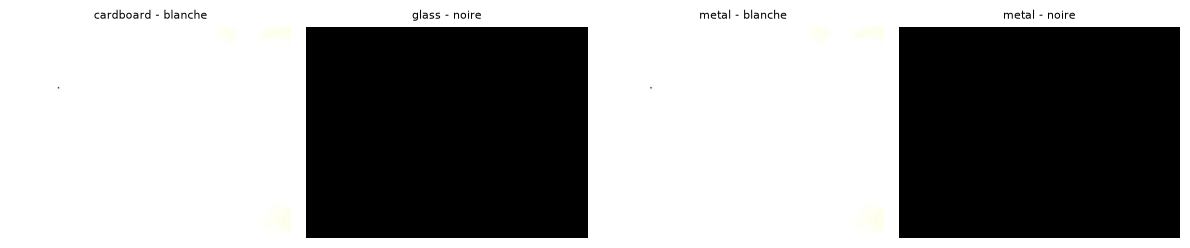

In [83]:
vides = df[df["vide"]]
n = len(vides)
if n > 0:
    plt.figure(figsize=(3 * min(n, 5), 3 * ((n - 1) // 5 + 1)))
    for i, (_, ligne) in enumerate(vides.iterrows()):
        plt.subplot((n - 1) // 5 + 1, min(n, 5), i + 1)
        plt.imshow(Image.open(ligne["chemin"]).convert("RGB"))
        plt.title(f"{ligne['classe']} - {ligne['type_vide']}", fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

Partie 4 – Détecter les différences de résolution 

1) Déterminer la résolution minimale, la résolution maximale, les résolutions les plus 
fréquentes et le nombre d'images par résolution. 

In [84]:
df_ok = df[~df["corrompue"]].copy()
df_ok["largeur"] = df_ok["largeur"].astype(int)
df_ok["hauteur"] = df_ok["hauteur"].astype(int)
df_ok["resolution"] = df_ok["largeur"].astype(str) + "x" + df_ok["hauteur"].astype(str)
df_ok["surface"] = df_ok["largeur"] * df_ok["hauteur"]

# 1) Résolution minimale et maximale (comparées par nombre total de pixels)
idx_min = df_ok["surface"].idxmin()
idx_max = df_ok["surface"].idxmax()
print("Résolution minimale :", df_ok.loc[idx_min, "resolution"], "->", df_ok.loc[idx_min, "nom"])
print("Résolution maximale :", df_ok.loc[idx_max, "resolution"], "->", df_ok.loc[idx_max, "nom"])

# Nombre d'images par résolution + les plus fréquentes
par_resolution = df_ok["resolution"].value_counts()
print("\nNombre de résolutions différentes :", len(par_resolution))
print("\nRésolutions les plus fréquentes :")
print(par_resolution.head(10))

Résolution minimale : 32x32 -> cardboard22.jpg
Résolution maximale : 512x384 -> cardboard1.jpg

Nombre de résolutions différentes : 4

Résolutions les plus fréquentes :
resolution
512x384    1013
32x32         5
48x32         4
40x40         4
Name: count, dtype: int64


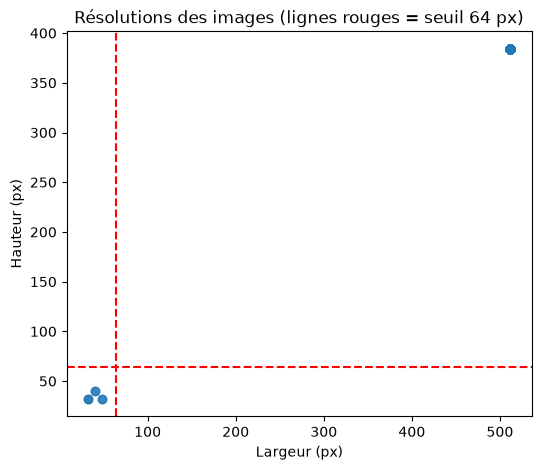

In [85]:
plt.figure(figsize=(6, 5))
plt.scatter(df_ok["largeur"], df_ok["hauteur"], alpha=0.4)
plt.axvline(64, color="red", linestyle="--")
plt.axhline(64, color="red", linestyle="--")
plt.xlabel("Largeur (px)")
plt.ylabel("Hauteur (px)")
plt.title("Résolutions des images (lignes rouges = seuil 64 px)")
plt.show()

2) On décide qu'une image doit avoir au minimum 64 × 64 pixels. Identifier toutes les images 
ne respectant pas cette contrainte. 

In [86]:
df["trop_petite"] = False
masque = (~df["corrompue"]) & ((df["largeur"] < 64) | (df["hauteur"] < 64))
df.loc[masque, "trop_petite"] = True

petites = df[df["trop_petite"]]
print(len(petites), "images trop petites")
print(petites[["nom", "classe", "largeur", "hauteur"]])

audit["Images trop petites"] = int(df["trop_petite"].sum())

13 images trop petites
                  nom     classe  largeur  hauteur
20   cardboard117.jpg  cardboard     48.0     32.0
77    cardboard22.jpg  cardboard     32.0     32.0
133   cardboard70.jpg  cardboard     40.0     40.0
171      glass100.jpg      glass     40.0     40.0
229       glass15.jpg      glass     48.0     32.0
268       glass21.jpg      glass     32.0     32.0
270       glass23.jpg      glass     32.0     32.0
383      metal121.jpg      metal     48.0     32.0
413        metal2.jpg      metal     32.0     32.0
421       metal26.jpg      metal     40.0     40.0
507       paper10.jpg      paper     32.0     32.0
707       paper54.jpg      paper     40.0     40.0
718       paper64.jpg      paper     48.0     32.0


Partie 5 – Détecter les différents canaux 
Déterminer le nombre d'images selon leur nombre de canaux.

In [87]:
# Nombre d'images selon le nombre de canaux
print(df_ok["nb_canaux"].value_counts().sort_index())

# Détail par mode (L = grayscale, RGB, RGBA, P = palette, etc.)
print(df_ok["mode"].value_counts())

# Croisement mode x nombre de canaux
print(pd.crosstab(df_ok["mode"], df_ok["nb_canaux"]))

nb_canaux
1.0       2
3.0    1006
4.0      18
Name: count, dtype: int64
mode
RGB     1006
RGBA      18
P          2
Name: count, dtype: int64
nb_canaux  1.0   3.0  4.0
mode                     
P            2     0    0
RGB          0  1006    0
RGBA         0     0   18


In [88]:
audit["Images grayscale"] = int((df_ok["mode"] == "L").sum())
audit["Images RGBA"] = int((df_ok["mode"] == "RGBA").sum())
print(audit)

{"total d'images": 1032, 'Images corrompues': 6, 'Images quasi vides': 4, 'Images trop petites': 13, 'Images grayscale': 0, 'Images RGBA': 18}


Partie 6 – Détecter les doublons 
Écrire et se servir d’une fonction qui détecte les doublons 
NB : Deux fichiers différents peuvent contenir exactement la même image.

In [89]:
import hashlib

def hash_fichier(chemin):
    with open(chemin, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

def hash_pixels(chemin):
    """Hash des pixels après conversion en RGB (le mode ne doit pas masquer un doublon)."""
    try:
        with Image.open(chemin) as img:
            arr = np.array(img.convert("RGB"))
        return hashlib.md5(str(arr.shape).encode() + arr.tobytes()).hexdigest()
    except Exception:
        return None   # image corrompue

def detecter_doublons(df):
    """Ajoute hash_fichier, hash_pixels et doublon (True pour toutes les copies sauf la première)."""
    df = df.copy()
    df["hash_fichier"] = df["chemin"].apply(hash_fichier)
    df["hash_pixels"] = df["chemin"].apply(hash_pixels)

    lisibles = ~df["corrompue"]
    df["doublon"] = False
    df.loc[lisibles, "doublon"] = df[lisibles].duplicated(subset="hash_pixels", keep="first")
    return df

df = detecter_doublons(df)

print("Doublons (copies en trop) :", df["doublon"].sum())
print("Doublons stricts (mêmes octets) :",
      df[~df["corrompue"]].duplicated(subset="hash_fichier", keep="first").sum())

Doublons (copies en trop) : 15
Doublons stricts (mêmes octets) : 15


In [90]:
groupes = df[~df["corrompue"]].groupby("hash_pixels")
groupes_dupliques = groupes.filter(lambda g: len(g) > 1).sort_values("hash_pixels")
print(groupes_dupliques[["hash_pixels", "nom", "classe"]].head(20))

# Même image présente dans plusieurs classes = très probablement une image mal classée
inter_classes = groupes.filter(lambda g: g["classe"].nunique() > 1)
print("\nImages en doublon entre classes différentes :", len(inter_classes))
print(inter_classes[["nom", "classe", "hash_pixels"]].sort_values("hash_pixels"))

audit["Doublons"] = int(df["doublon"].sum())

                          hash_pixels                      nom   classe
839  20d1f750946c4771bb2384084498650e         plastic171az.jpg  plastic
838  20d1f750946c4771bb2384084498650e           plastic171.jpg  plastic
732  223ff50158e97c4631cee0f26fedf752            paper77ty.jpg    paper
731  223ff50158e97c4631cee0f26fedf752              paper77.jpg    paper
980  24640038e1c4e89729e0e617c2a230ca          plasticx199.jpg  plastic
869  24640038e1c4e89729e0e617c2a230ca           plastic199.jpg  plastic
188  38c7295b2f0e9aa2061910e1304f4aac             glass115.jpg    glass
496  38c7295b2f0e9aa2061910e1304f4aac              metal91.jpg    metal
431  48558eac663ff9553cd70ac86e0ed85a              metal35.jpg    metal
432  48558eac663ff9553cd70ac86e0ed85a            metal35rt.jpg    metal
757  501bb1467a6acd96c186ffeeb722045b            paperer35.jpg    paper
686  501bb1467a6acd96c186ffeeb722045b              paper35.jpg    paper
643  68a352e810b0a38cdc981b6878886491           paper221kl.jpg  

Partie 7 : Détecter les images mal classées 
Effectuer un contrôle visuel pour détecter toute image mal classée. 

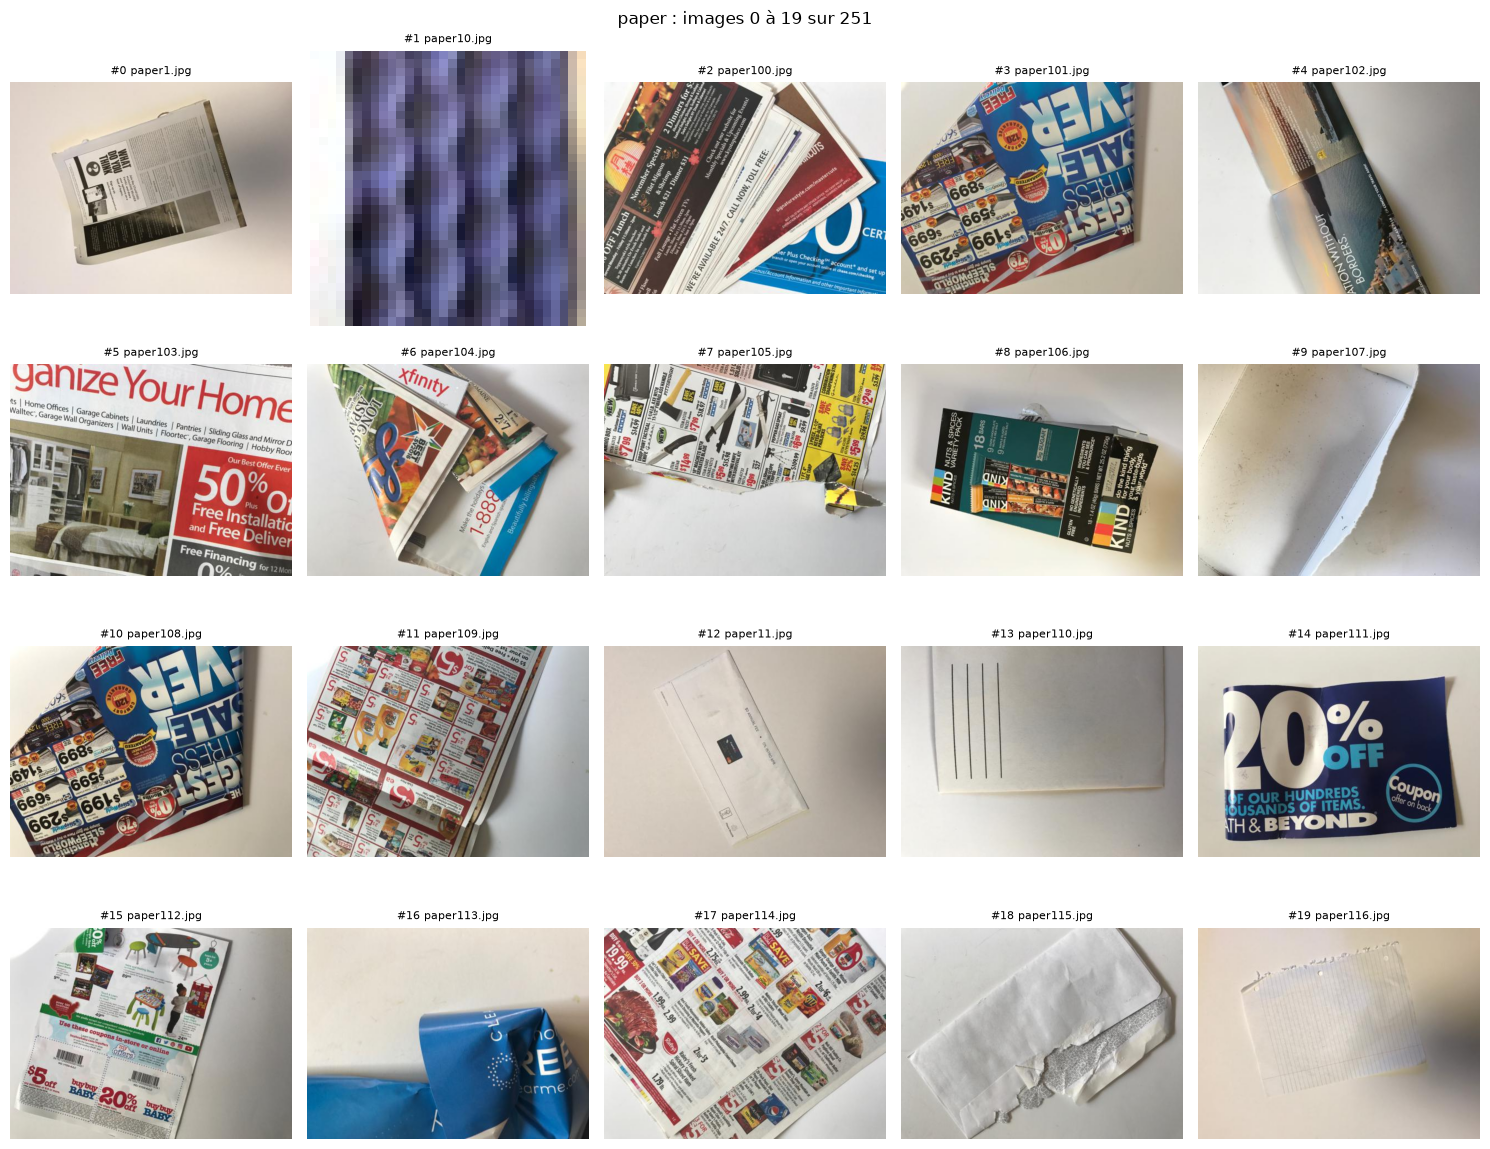

In [91]:
def afficher_grille(classe, debut=0, nb=20, colonnes=5):
    """Affiche nb images d'une classe (hors corrompues et vides) à partir de la position debut."""
    sous = df[(df["classe"] == classe) & (~df["corrompue"]) & (~df["vide"])].reset_index(drop=True)
    lot = sous.iloc[debut:debut + nb]
    lignes = (len(lot) - 1) // colonnes + 1

    plt.figure(figsize=(3 * colonnes, 3 * lignes))
    for i, (pos, ligne) in enumerate(lot.iterrows()):
        plt.subplot(lignes, colonnes, i + 1)
        plt.imshow(Image.open(ligne["chemin"]).convert("RGB"))
        plt.title(f"#{pos} {ligne['nom'][:18]}", fontsize=8)
        plt.axis("off")
    plt.suptitle(f"{classe} : images {debut} à {debut + len(lot) - 1} sur {len(sous)}")
    plt.tight_layout()
    plt.show()

afficher_grille("paper", debut=0)

In [92]:
def normaliser(chemin):
    return chemin.replace("\\", "/")

mal_classees = {
    "../data/raw/glass/glass12er.jpg": "cardboard",
    "../data/raw/metal/metal15.jpg": "trash",
    "../data/raw/metal/metal150.jpg": "paper",
    "../data/raw/metal/metal63.jpg": "plastic",
    "../data/raw/cardboard/cardboard86.jpg": "plastic",
    "../data/raw/cardboard/cardboard161.jpg": "glass",
    "../data/raw/metal/metal91.jpg": "glass",
    "../data/raw/glass/glass176.jpg": "plastic",
}
mal_classees_norm = {normaliser(k): v for k, v in mal_classees.items()}

df["chemin_norm"] = df["chemin"].apply(normaliser)
df["mal_classee"] = df["chemin_norm"].isin(mal_classees_norm.keys())
df["classe_reelle"] = df["chemin_norm"].map(mal_classees_norm)

print(df["mal_classee"].sum(), "images mal classées")
print(df[df["mal_classee"]][["nom", "classe", "classe_reelle"]])

audit["images mal classées"] = int(df["mal_classee"].sum())

8 images mal classées
                  nom     classe classe_reelle
70   cardboard161.jpg  cardboard         glass
151   cardboard86.jpg  cardboard       plastic
206     glass12er.jpg      glass     cardboard
258      glass176.jpg      glass       plastic
407       metal15.jpg      metal         trash
408      metal150.jpg      metal         paper
464       metal63.jpg      metal       plastic
496       metal91.jpg      metal         glass


In [93]:
# Forcer le doublon sur la bonne copie (glass176 est la mal classée, pas plastic152)
df.loc[df["chemin_norm"] == "../data/raw/glass/glass176.jpg", "doublon"] = True
df.loc[df["chemin_norm"] == "../data/raw/plastic/plastic152.jpg", "doublon"] = False

# Exclusion des images de test non pertinentes (aplat de bruit, pas un vrai déchet)
a_exclure_manuellement = [
    "../data/raw/cardboard/image-violet-512x384.gif",
    "../data/raw/glass/image-violet-512x384.gif",
]
df["exclusion_manuelle"] = df["chemin_norm"].isin(a_exclure_manuellement)

print("doublon glass176 :", df.loc[df["chemin_norm"] == "../data/raw/glass/glass176.jpg", "doublon"].values)
print("doublon plastic152 :", df.loc[df["chemin_norm"] == "../data/raw/plastic/plastic152.jpg", "doublon"].values)
print("exclusions manuelles :", df["exclusion_manuelle"].sum())

doublon glass176 : [ True]
doublon plastic152 : [False]
exclusions manuelles : 2


Partie 8 : Analyser le déséquilibre des classes 
Déterminer le nombre d'images par classe 

1032 images au départ -> 995 images conservées
           raw  cleaned
paper      252      246
plastic    224      221
glass      188      180
cardboard  169      162
metal      149      136
trash       50       50
raw      majoritaire : paper (252), minoritaire : trash (50), ratio = 5.04
cleaned  majoritaire : paper (246), minoritaire : trash (50), ratio = 4.92


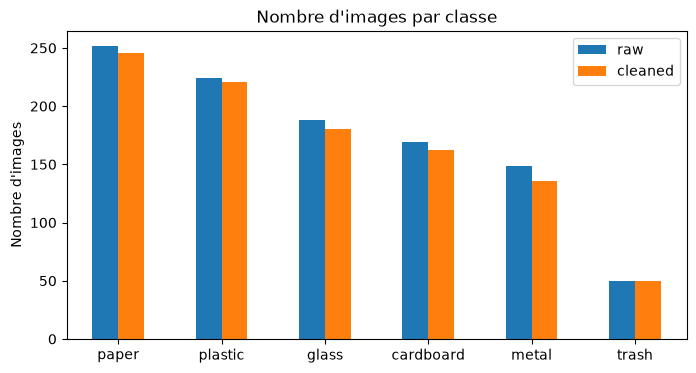

In [94]:
# Classe finale : la vraie classe si l'image était mal classée, sinon la classe du dossier
df["classe_finale"] = df["classe"]
df.loc[df["mal_classee"], "classe_finale"] = df.loc[df["mal_classee"], "classe_reelle"]

# Images conservées pour cleaned/
a_garder = (
    (~df["corrompue"])
    & (~df["vide"])
    & (~df["trop_petite"])
    & (~df["doublon"])
    & (~df["exclusion_manuelle"])
)
df["gardee"] = a_garder
df_propre = df[df["gardee"]].copy()

print(len(df), "images au départ ->", len(df_propre), "images conservées")

comptage = pd.DataFrame({
    "raw": df["classe"].value_counts(),
    "cleaned": df_propre["classe_finale"].value_counts(),
}).fillna(0).astype(int)
print(comptage)

for col in ["raw", "cleaned"]:
    maj, mino = comptage[col].idxmax(), comptage[col].idxmin()
    print(f"{col:8s} majoritaire : {maj} ({comptage[col].max()}), "
          f"minoritaire : {mino} ({comptage[col].min()}), "
          f"ratio = {comptage[col].max() / comptage[col].min():.2f}")

comptage.plot(kind="bar", figsize=(8, 4), title="Nombre d'images par classe")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=0)
plt.show()

In [95]:
audit_df = pd.DataFrame(list(audit.items()), columns=["indicateur", "valeur"])
print(audit_df)
audit_df.to_csv(f"{REPORTS_DIR}/audit_images.csv", index=False)

            indicateur  valeur
0       total d'images    1032
1    Images corrompues       6
2   Images quasi vides       4
3  Images trop petites      13
4     Images grayscale       0
5          Images RGBA      18
6             Doublons      15
7  images mal classées       8


Partie 9 : Redimensionnement 
Redimensionner toutes les images à 224 × 224. 
NB : Redimensionnement avec conservation des proportions et ajout éventuel de padding

In [96]:
TAILLE = 224

def vers_rgb(img):
    """Convertit n'importe quel mode en RGB (transparence collée sur fond blanc)."""
    if img.mode in ("RGBA", "LA") or (img.mode == "P" and "transparency" in img.info):
        img = img.convert("RGBA")
        fond = Image.new("RGB", img.size, (255, 255, 255))
        fond.paste(img, mask=img.split()[-1])
        return fond
    return img.convert("RGB")

def redimensionner_avec_padding(img, taille=TAILLE, couleur_padding=(0, 0, 0)):
    """Redimensionne en gardant les proportions, puis centre sur un canevas taille x taille."""
    img = vers_rgb(img)
    largeur, hauteur = img.size
    echelle = taille / max(largeur, hauteur)
    nouvelle_largeur = max(1, round(largeur * echelle))
    nouvelle_hauteur = max(1, round(hauteur * echelle))
    img = img.resize((nouvelle_largeur, nouvelle_hauteur), Image.LANCZOS)

    canevas = Image.new("RGB", (taille, taille), couleur_padding)
    x = (taille - nouvelle_largeur) // 2
    y = (taille - nouvelle_hauteur) // 2
    canevas.paste(img, (x, y))
    return canevas

In [97]:
compteur = 0
for _, ligne in df_propre.iterrows():
    nom_sans_ext = ligne["nom"].rsplit(".", 1)[0]
    sortie = f"{CLEAN_DIR}/{ligne['classe_finale']}/{ligne['classe']}_{nom_sans_ext}.png"
    with Image.open(ligne["chemin"]) as img:
        redimensionner_avec_padding(img).save(sortie)
    compteur += 1

print(compteur, "images écrites dans cleaned/")

995 images écrites dans cleaned/


In [98]:
for classe in CLASSES:
    fichiers = glob.glob(f"{CLEAN_DIR}/{classe}/*.png")
    print(f"{classe:10s} : {len(fichiers)} images")

cardboard  : 162 images
glass      : 180 images
metal      : 136 images
paper      : 246 images
plastic    : 221 images
trash      : 50 images


Partie 10 : Uniformisation des canaux 
Convertir toutes les images en RGB 

In [99]:
modes_trouves = set()
for classe in CLASSES:
    for f in glob.glob(f"{CLEAN_DIR}/{classe}/*.png"):
        with Image.open(f) as img:
            modes_trouves.add(img.mode)

print("Modes présents dans cleaned/ :", modes_trouves)
assert modes_trouves == {"RGB"}, "Il reste des images non converties en RGB !"

Modes présents dans cleaned/ : {'RGB'}


Partie 11 : Mise à l'échelle des pixels 
Normaliser les valeurs des pixels de toutes les images 

In [100]:
def charger_normalise(chemin):
    """Charge une image PNG de cleaned/ et renvoie un tableau float32 dans [0, 1]."""
    with Image.open(chemin) as img:
        arr = np.array(img, dtype=np.float32) / 255.0
    return arr

# Test sur une image
exemple = glob.glob(f"{CLEAN_DIR}/glass/*.png")[0]
arr = charger_normalise(exemple)
print(arr.shape, arr.dtype, arr.min(), arr.max())

(224, 224, 3) float32 0.0 1.0


Partie 12 : Découpage Train/Validation/Test 
Découper le dataset nettoyé (cleaned) en trois sous-ensembles : train, validation et test

In [101]:
SPLITS = ["train", "valid", "test"]

for split in SPLITS:
    for classe in CLASSES:
        test = f"../data/{split}/{classe}"
        try:
            with open(f"{test}/.test_ecriture", "w") as f:
                f.write("ok")
        except FileNotFoundError:
            print(f"MANQUANT : {test}")

print("Vérification terminée (aucune ligne MANQUANT = tout est prêt)")

Vérification terminée (aucune ligne MANQUANT = tout est prêt)


In [102]:
import random
import shutil

random.seed(42)
PROPORTIONS = {"train": 0.7, "valid": 0.15, "test": 0.15}

for classe in CLASSES:
    fichiers = glob.glob(f"{CLEAN_DIR}/{classe}/*.png")
    random.shuffle(fichiers)

    n = len(fichiers)
    n_train = round(n * PROPORTIONS["train"])
    n_valid = round(n * PROPORTIONS["valid"])

    groupes = {
        "train": fichiers[:n_train],
        "valid": fichiers[n_train:n_train + n_valid],
        "test": fichiers[n_train + n_valid:],
    }

    for split, liste in groupes.items():
        for chemin_source in liste:
            nom = chemin_source.replace("\\", "/").split("/")[-1]
            shutil.copy(chemin_source, f"../data/{split}/{classe}/{nom}")

    print(f"{classe:10s} : train={len(groupes['train'])}, "
          f"valid={len(groupes['valid'])}, test={len(groupes['test'])}")

cardboard  : train=113, valid=24, test=25
glass      : train=126, valid=27, test=27
metal      : train=95, valid=20, test=21
paper      : train=172, valid=37, test=37
plastic    : train=155, valid=33, test=33
trash      : train=35, valid=8, test=7


In [103]:
for split in PROPORTIONS:
    total = 0
    for classe in CLASSES:
        n = len(glob.glob(f"../data/{split}/{classe}/*.png"))
        total += n
    print(f"{split:6s} : {total} images")

train  : 696 images
valid  : 149 images
test   : 150 images


Partie 13 : Data Augmentation 
1) A l’aide de Keras, appliquer à la classe minoritaire de la « data augmentation » en utilisant des 
transformations comme rotation légère, retournement horizontal, zoom, translation, variation 
de luminosité, variation de contraste, légère variation de couleur, … 
2) Pourquoi éviter de faire la « data augmentation » avant le découpage du dataset ? 